Building the weighted numeric + categorical + text feature vector, and picking the weights (`0.25` / `0.40` / `0.35`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson"

In [3]:
_WEIGHT_SENTINEL = 999_999_999

df_raw = pd.read_json(DATA_PATH, lines=True)
df_raw = df_raw.drop_duplicates(subset=["uniq_id"]).reset_index(drop=True)

df_raw["weight"] = pd.to_numeric(df_raw["weight"], errors="coerce")
df_raw.loc[df_raw["weight"] >= _WEIGHT_SENTINEL, "weight"] = np.nan

for col in ["sales_price", "rating", "no__of_reviews", "no__of_sellers",
            "discount_percentage", "sales_rank_in_parent_category",
            "sales_rank_in_child_category", "no__of_offers"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

for col in ["amazon_prime__y_or_n", "best_seller_tag__y_or_n"]:
    if col in df_raw.columns:
        df_raw[col] = (df_raw[col].fillna("N").str.upper() == "Y").astype(float)

df_raw["brand"]  = df_raw["brand"].fillna("").str.lower().str.strip()
df_raw["colour"] = df_raw["colour"].fillna("").str.lower().str.strip()

# text group: product name + keywords + brand + colour
df_raw["text_blob"] = (
    df_raw["product_name"].fillna("") + " " +
    df_raw["meta_keywords"].fillna("") + " " +
    df_raw["brand"] + " " +
    df_raw["colour"]
).str.strip()

def extract_category(val):
    if isinstance(val, dict):
        keys_list = [k for k in val if k not in ("", None)]
        return str(keys_list[0]) if keys_list else ""
    return str(val) if val else ""

def extract_child_category(val):
    if isinstance(val, dict):
        keys_list = [k for k in val if k not in ("", None)]
        return str(keys_list[1]) if len(keys_list) >= 2 else ""
    return ""

df_raw["category"]       = df_raw["parent___child_category__all"].apply(extract_category)
df_raw["child_category"] = df_raw["parent___child_category__all"].apply(extract_child_category)

# categorical group: pure subcategory label — brand/colour moved to text to prevent IDF skew
df_raw["cat_blob"] = df_raw["child_category"].fillna("").str.strip()

if df_raw.index.name != "uniq_id" and "uniq_id" in df_raw.columns:
    df_raw = df_raw.set_index("uniq_id")

print(f"Loaded {len(df_raw):,} products")
print(f"\nTop 5 cat_blob values (should be subcategory labels, not brand names):")
print(df_raw["cat_blob"].value_counts().head(5))
df_raw.head(3)


Loaded 30,000 products

Top 5 cat_blob values (should be subcategory labels, not brand names):
cat_blob
                      5149
WomensKurtasKurtis    3534
MensT_Shirts          3385
WomensSarees          1808
MensFormalShirts      1060
Name: count, dtype: int64


,crawl_timestamp,asin,product_url,product_name,image_urls__small,medium,large,browsenode,brand,sales_price,...,left_in_stock,no__of_offers,no__of_sellers,technical_details__k_v_pairs,formats___editions,name_of_author_for_books,text_blob,category,child_category,cat_blob
uniq_id,,,,,,,,,,,,,,,,,,,,,
26d41bdc1495de290bc8e6062d927729,2020-02-07 05:11:36 +0000,B07STS2W9T,https://www.amazon.in/Facon-Kalamkari-Handbloc...,LA' Facon Cotton Kalamkari Handblock Saree Blo...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968255e+09,la' facon,200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,LA' Facon Cotton Kalamkari Handblock Saree Blo...,ClothingAccessories,WomensKurtasKurtis,WomensKurtasKurtis
410c62298852e68f34c35560f2311e5a,2020-02-07 08:45:56 +0000,B07N6TD2WL,https://www.amazon.in/Sf-Jeans-Pantaloons-T-Sh...,Sf Jeans By Pantaloons Men's Plain Slim fit T-...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968123e+09,,265.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Sf Jeans By Pantaloons Men's Plain Slim fit T-...,ClothingAccessories,MensT_Shirts,MensT_Shirts
52e31bb31680b0ec73de0d781a23cc0a,2020-02-06 11:09:38 +0000,B07WJ6WPN1,https://www.amazon.in/LOVISTA-Traditional-Prin...,LOVISTA Cotton Gota Patti Tassel Traditional P...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,https://images-na.ssl-images-amazon.com/images...,1.968255e+09,lovista,660.0,...,NaN,NaN,NaN,NaN,NaN,NaN,LOVISTA Cotton Gota Patti Tassel Traditional P...,ClothingAccessories,WomensKurtasKurtis,WomensKurtasKurtis


In [4]:
_NUMERIC_COLS_CANDIDATE = [
    "sales_price", "rating", "weight", "no__of_reviews", "no__of_sellers",
    "discount_percentage", "parent_rank", "is_prime", "is_bestseller",
]

null_rates = {
    c: df_raw[c].isna().mean()
    for c in _NUMERIC_COLS_CANDIDATE
    if c in df_raw.columns
}

In [5]:
print("Null rates per numeric column:")
for col, rate in sorted(null_rates.items(), key=lambda x: -x[1]):
    status = "EXCLUDED (all NaN)" if rate == 1.0 else f"{rate:.1%} null"
    print(f"  {col:<25} {status}")

Null rates per numeric column:
  weight                    EXCLUDED (all NaN)
  discount_percentage       EXCLUDED (all NaN)
  no__of_sellers            96.6% null
  no__of_reviews            88.5% null
  sales_price               9.6% null
  rating                    0.0% null


In [6]:
numeric_cols = [
    c for c in _NUMERIC_COLS_CANDIDATE
    if c in df_raw.columns and df_raw[c].notna().any()
]
print(f"Using {len(numeric_cols)} numeric columns: {numeric_cols}")

raw_numeric = df_raw[numeric_cols].values.astype(np.float64)

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

numeric_features = scaler.fit_transform(imputer.fit_transform(raw_numeric))
print(f"\nNumeric feature matrix shape: {numeric_features.shape}")

Using 4 numeric columns: ['sales_price', 'rating', 'no__of_reviews', 'no__of_sellers']

Numeric feature matrix shape: (30000, 4)


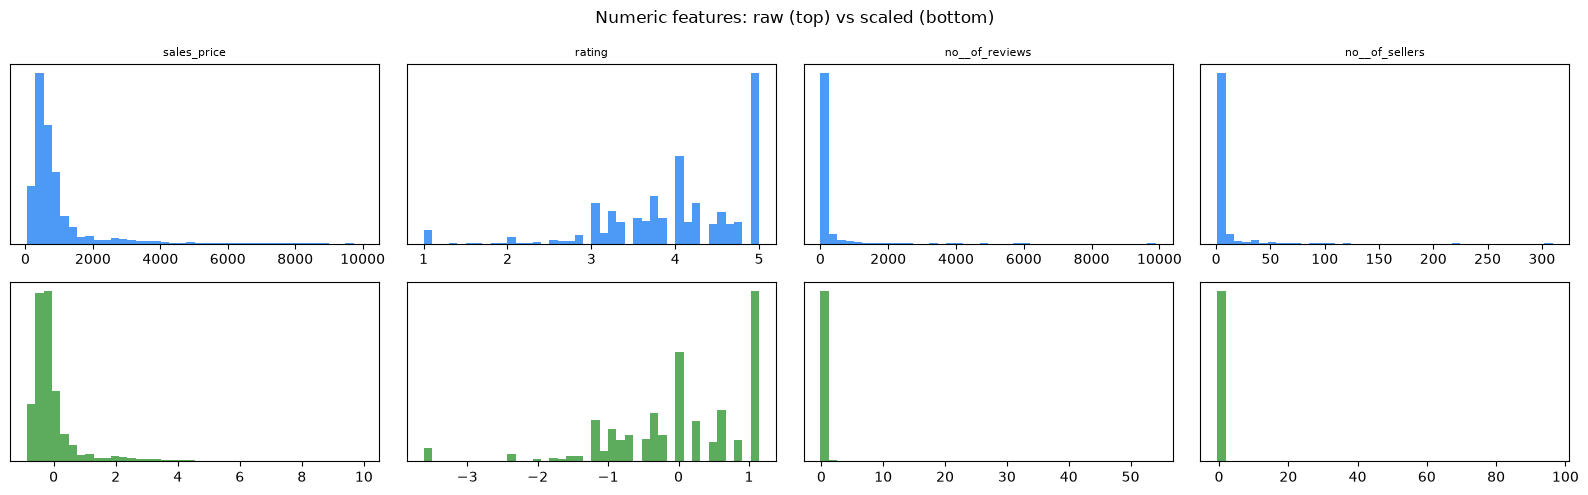

In [7]:
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(16, 5))
fig.suptitle("Numeric features: raw (top) vs scaled (bottom)", fontsize=12)

for i, col in enumerate(numeric_cols):
    raw_vals = df_raw[col].dropna()
    axes[0, i].hist(raw_vals, bins=40, color="#0070F2", alpha=0.7)
    axes[0, i].set_title(col, fontsize=8)
    axes[0, i].set_yticks([])

    axes[1, i].hist(numeric_features[:, i], bins=40, color="#188918", alpha=0.7)
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

### Isolating the category signal

`cat_blob` here is the subcategory label alone (e.g. `WomensSarees`), not blended with brand/colour. An earlier try put `child_category` inside the text blob and gave brand+colour their own TF-IDF group — category ended up diluted by SVD, and a niche brand's higher IDF could outweigh it.

In [8]:
cat_tfidf = TfidfVectorizer(
    max_features=500,
    min_df=1,
    analyzer="word",
    sublinear_tf=True,
)

cat_matrix = cat_tfidf.fit_transform(df_raw["cat_blob"].fillna("").astype(str))
cat_features = cat_matrix.toarray()

print(f"Categorical TF-IDF shape: {cat_features.shape}")
print(f"Vocabulary size: {len(cat_tfidf.vocabulary_)}")

# cat_blob is now pure subcategory labels — vocabulary should be category names, not brand names
print(f"\nAll vocabulary terms (subcategory labels):")
print(sorted(cat_tfidf.vocabulary_.keys()))


Categorical TF-IDF shape: (30000, 218)
Vocabulary size: 218

All vocabulary terms (subcategory labels):
['babycarriers', 'bagorganizers', 'boysbelts', 'boysboxershorts', 'boysclothingsets', 'boysdhotismunduslungis', 'boysdungarees', 'boysethnicwear', 'boysgloves', 'boyshandkerchiefs', 'boyshatscaps', 'boysjackets', 'boysjeans', 'boyskurtasets', 'boyspants', 'boyspolos', 'boyspyjamasets', 'boysrainwear', 'boyssherwanis', 'boysshirts', 'boysshorts', 'boyssleepsuits', 'boyssleepwear', 'boyssocks', 'boyssportsshirtstees', 'boyssportsshorts', 'boyssportstrousers', 'boyssportswear', 'boyssportswearcaps', 'boyssuits', 'boyssweaters', 'boyssweatshirtshoodies', 'boyst_shirts', 'boyst_shirtspolos', 'boysthermalunderwear', 'boysties', 'boysunderwearbriefs', 'boysunderweartrunks', 'boysunderwearvests', 'computerbluelightblockingglasses', 'exercisefitnessclothing', 'exercisefitnessgloves', 'fanshop', 'fashion', 'footballclothing', 'girlsbeginnersbras', 'girlsbelts', 'girlsbikinis', 'girlsclothing',

Unique child categories: 219
Unique cat_blob values:  219


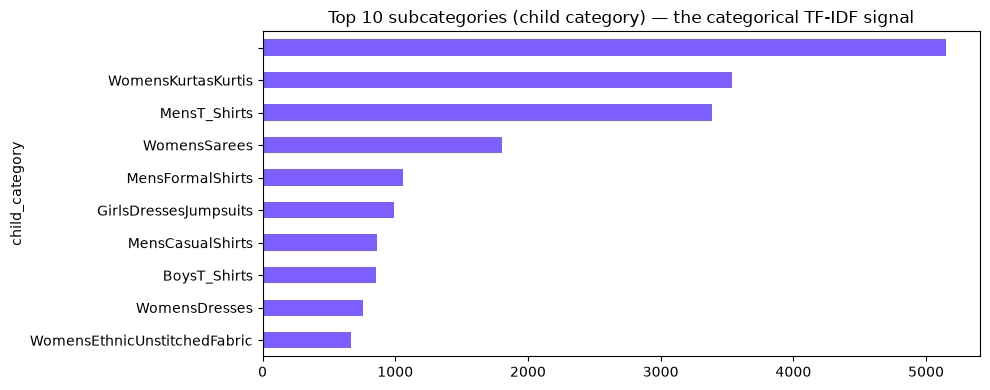

In [9]:
print(f"Unique child categories: {df_raw['child_category'].nunique():,}")
print(f"Unique cat_blob values:  {df_raw['cat_blob'].nunique():,}")

top_subcats = df_raw["child_category"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
top_subcats.plot(kind="barh", ax=ax, color="#5D36FF", alpha=0.8)
ax.set_title("Top 10 subcategories (child category) — the categorical TF-IDF signal")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
text_tfidf = TfidfVectorizer(
    max_features=8000,
    min_df=2,
    ngram_range=(1, 2),
    analyzer="word",
    sublinear_tf=True,
    stop_words="english",
)

text_sparse = text_tfidf.fit_transform(df_raw["text_blob"].fillna("").astype(str))
print(f"TF-IDF sparse matrix shape: {text_sparse.shape}")
print(f"Sparsity: {1 - text_sparse.nnz / (text_sparse.shape[0] * text_sparse.shape[1]):.2%}")

TF-IDF sparse matrix shape: (30000, 8000)
Sparsity: 99.81%


After SVD shape: (30000, 100)
Explained variance (100 components): 28.23%


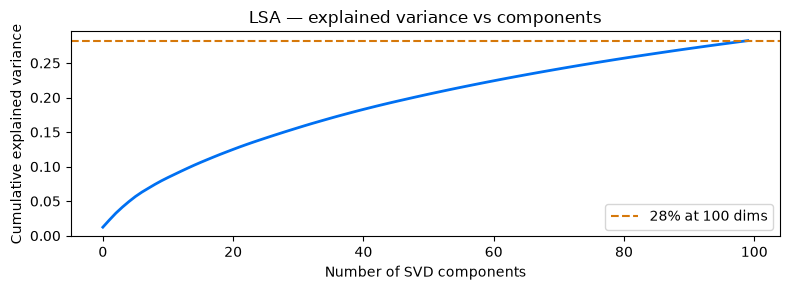

In [11]:
svd = TruncatedSVD(n_components=100, random_state=42)
text_features = svd.fit_transform(text_sparse)

print(f"After SVD shape: {text_features.shape}")
print(f"Explained variance (100 components): {svd.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(np.cumsum(svd.explained_variance_ratio_), color="#0070F2", linewidth=2)
ax.axhline(svd.explained_variance_ratio_.sum(), color="#D6780A", linestyle="--", label=f"{svd.explained_variance_ratio_.sum():.0%} at 100 dims")
ax.set_xlabel("Number of SVD components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("LSA — explained variance vs components")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
W_NUMERIC      = 0.25
W_CATEGORICAL  = 0.40   # pure subcategory — dominant signal (raised from 0.35)
W_TEXT         = 0.35   # product name + keywords + brand + colour (lowered from 0.40)

combined = np.hstack([
    numeric_features  * W_NUMERIC,
    cat_features      * W_CATEGORICAL,
    text_features     * W_TEXT,
]).astype(np.float32)

print(f"Combined (weighted) shape: {combined.shape}")
print(f"  Numeric dims:     {numeric_features.shape[1]}  × {W_NUMERIC} = {numeric_features.shape[1] * W_NUMERIC:.0f} effective")
print(f"  Categorical dims: {cat_features.shape[1]}  × {W_CATEGORICAL}  (subcategory is highest-weight signal)")
print(f"  Text dims:        {text_features.shape[1]}  × {W_TEXT}")
print(f"  Total dims:       {combined.shape[1]}")


Combined (weighted) shape: (30000, 322)
  Numeric dims:     4  × 0.25 = 1 effective
  Categorical dims: 218  × 0.4  (subcategory is highest-weight signal)
  Text dims:        100  × 0.35
  Total dims:       322


In [13]:
feature_matrix = normalize(combined, norm="l2")
norms = np.linalg.norm(feature_matrix, axis=1)
print(f"All vectors unit norm? {np.allclose(norms, 1.0, atol=1e-5)}")
print(f"Norm min: {norms.min():.6f}  max: {norms.max():.6f}")
print(f"\nFinal feature matrix: {feature_matrix.shape}  dtype: {feature_matrix.dtype}")
print(f"Memory: {feature_matrix.nbytes / 1e6:.1f} MB")

All vectors unit norm? True
Norm min: 1.000000  max: 1.000000

Final feature matrix: (30000, 322)  dtype: float32
Memory: 38.6 MB


In [14]:
sample_id   = df_raw.index[0]
sample_idx  = 0
sample_row  = df_raw.iloc[sample_idx]

print(f"Query product: {sample_id}")
print(f"  Name:   {sample_row['product_name']}")
print(f"  Brand:  {sample_row['brand']}")
print(f"  Colour: {sample_row['colour']}")
print(f"  Price:  {sample_row['sales_price']}")

Query product: 26d41bdc1495de290bc8e6062d927729
  Name:   LA' Facon Cotton Kalamkari Handblock Saree Blouse Fabric 100 cms Black Base Dancers (Cotton)
  Brand:  la' facon
  Colour: 
  Price:  200.0


In [15]:
query_vec = feature_matrix[sample_idx].reshape(1, -1)
scores    = cosine_similarity(query_vec, feature_matrix)[0]

top_k     = np.argsort(scores)[::-1][1:11]  # skip self (rank 0)

print(f"\nTop 10 similar products to: '{sample_row['product_name'][:60]}'")
print("-" * 80)
for rank, idx in enumerate(top_k, 1):
    pid  = df_raw.index[idx]
    row  = df_raw.iloc[idx]
    print(f"{rank:2}. [{scores[idx]:.4f}] {str(row['product_name'])[:55]:<55} | {row['brand']:<15} | ₹{row['sales_price']}")


Top 10 similar products to: 'LA' Facon Cotton Kalamkari Handblock Saree Blouse Fabric 100'
--------------------------------------------------------------------------------
 1. [1.0000] LA' Facon Cotton Kalamkari Handblock Saree Blouse Fabri | la' facon       | ₹200.0
 2. [0.9770] Drapes Women's Kurtis White & Black Polka Dots Printed  | drapes          | ₹319.0
 3. [0.9745] Serein Women's Top                                      | serein          | ₹294.0
 4. [0.9732] Indi lite Women pink cotton princess cut Kurta          |                 | ₹368.0
 5. [0.9667] NEO NATIVES 100% Cotton Khadi Kurta Comes with a Fun Mo | neo natives     | ₹549.0
 6. [0.9667] NEO NATIVES 100% Cotton Khadi Kurta Comes with a Fun Mo | neo natives     | ₹549.0
 7. [0.9659] HASHTAG 18 Women's Mustard&Red Cambric Gold Print A-lin | hashtag 18      | ₹324.0
 8. [0.9621] NEO NATIVES 100% Khadi Cotton Designer Kurta Shirt (wit | neo natives     | ₹549.0
 9. [0.9616] PURE COMFORT Women's Kurti.                   

In [16]:
sample_idx = 0
sample_id  = df_raw.index[sample_idx]
sample_row = df_raw.iloc[sample_idx]

def build_features(df, w_n=0.25, w_c=0.40, w_t=0.35):
    raw_numeric = df[numeric_cols].values.astype(np.float64)
    num_f = scaler.transform(imputer.transform(raw_numeric))
    cat_f = cat_tfidf.transform(df["cat_blob"].fillna("").astype(str)).toarray()
    txt_f = svd.transform(text_tfidf.transform(df["text_blob"].fillna("").astype(str)))
    combined = np.hstack([num_f * w_n, cat_f * w_c, txt_f * w_t]).astype(np.float32)
    return normalize(combined, norm="l2")

configs = {
    "category-heavy (current)": (0.25, 0.40, 0.35),
    "equal weights":             (0.33, 0.33, 0.33),
    "numeric-heavy":             (0.50, 0.25, 0.25),
    "text-heavy":                (0.20, 0.25, 0.55),
}

print(f"Query: '{sample_row['product_name'][:55]}'\n")
for label, (w_n, w_c, w_t) in configs.items():
    fm   = build_features(df_raw, w_n, w_c, w_t)
    q    = fm[sample_idx].reshape(1, -1)
    sc   = cosine_similarity(q, fm)[0]
    top5 = np.argsort(sc)[::-1][1:6]
    names = [str(df_raw.iloc[i]["product_name"])[:35] for i in top5]
    print(f"[{label}]")
    for n in names:
        print(f"  • {n}")
    print()


Query: 'LA' Facon Cotton Kalamkari Handblock Saree Blouse Fabri'

[category-heavy (current)]
  • LA' Facon Cotton Kalamkari Handbloc
  • Drapes Women's Kurtis White & Black
  • Serein Women's Top
  • Indi lite Women pink cotton princes
  • NEO NATIVES 100% Cotton Khadi Kurta

[equal weights]
  • LA' Facon Cotton Kalamkari Handbloc
  • Drapes Women's Kurtis White & Black
  • Serein Women's Top
  • Indi lite Women pink cotton princes
  • HASHTAG 18 Women's Mustard&Red Camb

[numeric-heavy]
  • LA' Facon Cotton Kalamkari Handbloc
  • Serein Women's Top
  • Drapes Women's Kurtis White & Black
  • HASHTAG 18 Women's Mustard&Red Camb
  • Indi lite Women pink cotton princes

[text-heavy]
  • LA' Facon Cotton Kalamkari Handbloc
  • Drapes Women's Kurtis White & Black
  • NEO NATIVES 100% Cotton Khadi Kurta
  • NEO NATIVES 100% Cotton Khadi Kurta
  • Indi lite Women pink cotton princes

